# Klasifikasi DemogPairs Menggunakan ViT (Wajah dan Umur) & Gaussian Naive Bayes

In [1]:
import numpy as np
import utils as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

joblib.parallel_backend('threading')

C:\Users\Rezky\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
vggface_features = joblib.load('features/demogpairs_vit-age.pkl')
emotion_features = joblib.load('features/demogpairs_vit-face.pkl')
features = {}
for d in tqdm(data):
    key = d['image_path']
    features[key] = np.array(list(emotion_features[key]) + list(vggface_features[key]))
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

100%|██████████████████████████████████████████████████████████████████████████| 10800/10800 [00:02<00:00, 3771.77it/s]

Jumlah fitur per gambar: 1536


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
var_smoothing_values = np.logspace(-9, 2, 40)  # dari 1e-9 sampai 1e2, 40 nilai

grid_params = [
    {
        'classifier': [GaussianNB()],
        'classifier__var_smoothing': var_smoothing_values
    }
]

pipeline = Pipeline(steps=[
    ('classifier', None)
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.8),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

GaussianNB: 40 kombinasi


## Klasifikasi

Mengevaluasi model: GaussianNB
Fitting 5 folds for each of 40 candidates, totalling 200 fits


{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.04124626382901348)}


Accuracy  : 0.8046296296296296
Precision : 0.8065036636885344
Recall    : 0.8046296296296296
F1 Score  : 0.8029095116806602
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       360
           1       0.86      0.87      0.86       360
           2       0.74      0.77      0.76       360
           3       0.81      0.90      0.85       360
           4       0.84      0.65      0.73       360
           5       0.76      0.79      0.78       360

    accuracy                           0.80      2160
   macro avg       0.81      0.80      0.80      2160
weighted avg       0.81      0.80      0.80      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9453703703703704,0.827027027027027,0.85,0.8383561643835616
White_Females,0.9537037037037037,0.855191256830601,0.8694444444444445,0.8622589531680441
Asian_Males,0.9171296296296296,0.7426273458445041,0.7694444444444445,0.7557980900409277
White_Males,0.9472222222222222,0.8059701492537313,0.9,0.8503937007874016
Black_Females,0.9217592592592593,0.8447653429602888,0.65,0.7346938775510204
Asian_Females,0.924074074074074,0.7634408602150538,0.7888888888888889,0.7759562841530054


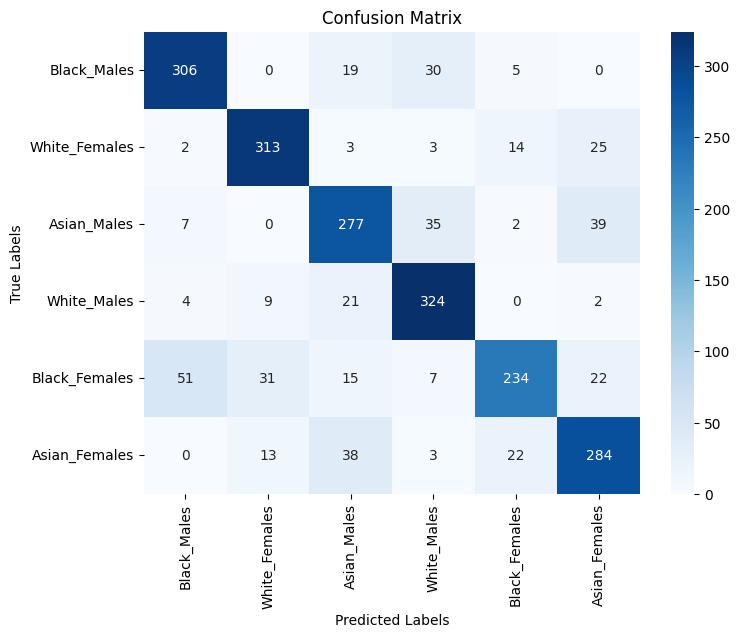

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
GaussianNB,models/clf_demogpairs_gnb_vit-face-age_GaussianNB.pkl,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.04124626382901348)}",0.8046296296296296,0.8029095116806602,0.8065036636885344,0.8046296296296296,40


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_gnb_vit-face-age_',
    results_path='results/demogpairs_gnb_vit-face-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_gnb_vit-face-age_GaussianNB.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 168.0,
 'days': 0,
 'hours': 0,
 'minutes': 2,
 'seconds': 48.0,
 'text': '0 hari 0 jam 2 menit 48.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 111.0,
 'days': 0,
 'hours': 0,
 'minutes': 1,
 'seconds': 51.0,
 'text': '0 hari 0 jam 1 menit 51.0 detik'}

In [9]:
_dtable = u.display_table(fold_results, n_items=[4, 4], column_widths=['5%', '45%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy Mean,F1 Score Mean,Precision Mean,Recall Mean,Train Time Mean
1,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.04124626382901348)}",0.8351,0.8264,0.8212,0.8235,0.8189,0.825,0.8236,0.8273,0.825,0.5407
2,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.021544346900318822)}",0.8339,0.8235,0.8218,0.827,0.8183,0.8249,0.8235,0.8268,0.8249,0.5631
3,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.07896522868499734)}",0.8362,0.8275,0.8229,0.8235,0.8142,0.8249,0.8234,0.8279,0.8249,0.5827
4,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.0058780160722749115)}",0.8356,0.8235,0.8212,0.8258,0.8166,0.8245,0.8232,0.8264,0.8245,0.5398
...,...,...,...,...,...,...,...,...,...,...,...
37,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(52.233450742668325)}",0.8223,0.8235,0.8067,0.8038,0.8102,0.8133,0.8119,0.8269,0.8133,0.549
38,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(27.283333764867695)}",0.8223,0.8229,0.8067,0.8038,0.8102,0.8132,0.8118,0.8267,0.8132,0.5942
39,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(100.0)}",0.8218,0.8229,0.8067,0.8038,0.8102,0.8131,0.8117,0.8267,0.8131,0.5734
40,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(14.251026703029963)}",0.8218,0.8223,0.8067,0.8044,0.8096,0.813,0.8116,0.8262,0.813,0.5631
